# 01 - Perfil e auditoria dos dados
**Projeto:** PI 4CCOMP 2026/2, CTI Global, Grupo 6
**Fase CRISP-DM:** Entender os Dados
**Fonte:** Demonstrativo Fecap v3.csv (CTI Global, recebido em 21/08/2026)

Objetivo: descrever a estrutura do arquivo, explorar seu conteúdo
e verificar a qualidade dos dados antes de qualquer transformação.

**Contexto informado pela CTI (08/09/2026):** os dados são **projetados**, não históricos, e
representam uma concessionária de infraestrutura. Os 1.200 cenários vêm de uma **simulação de
Monte Carlo**: são 1.200 futuros possíveis da mesma concessão, não 1.200 empresas. Por convenção
acadêmica, **Ano 1 = 2027 até Ano 12 = 2038**. O Ano 12 é o **encerramento da concessão**.

**Revisão de 15/09/2026:** corrigida a verificação do balanço (convenção de sinais) e as
interpretações das linhas sem nome de conta e dos cenários repetidos.

**Revisão de 22/09/2026:** o notebook passou a rodar sozinho no Google Colab; as saídas não mostram mais
linhas individuais da base; a tabela cruzada usa `pivot`, que recusa chaves repetidas; e foram corrigidas
as leituras da faixa da receita e da dispersão do caixa, que não se sustentavam nos dados.

## Como executar

**Na máquina local:** abra o notebook com o kernel do ambiente `.venv` e execute as células em ordem.
A base precisa estar em `src/data/raw/Demonstrativo Fecap v3.csv`.

**No Google Colab:** a célula abaixo clona o repositório, mostra o commit usado e copia a base a partir do
Google Drive de quem executa. Ajuste `CSV_NO_DRIVE` para o caminho onde a base está no seu Drive. A base é
confidencial: fica no Drive de quem tem autorização e não vai para o repositório. Fora do Colab, a célula
não faz nada.

In [1]:
import os
import shutil
import subprocess
import sys

EM_COLAB = "google.colab" in sys.modules

if EM_COLAB:
    # Caminho da cópia autorizada da base no Google Drive de quem executa: ajuste se necessário
    CSV_NO_DRIVE = "/content/drive/MyDrive/Base CTI/Demonstrativo Fecap v3.csv"
    from google.colab import drive

    drive.mount("/content/drive")
    if not os.path.exists(CSV_NO_DRIVE):
        raise FileNotFoundError(f"Base não encontrada em {CSV_NO_DRIVE}. Ajuste CSV_NO_DRIVE.")
    if not os.path.exists("/content/Projeto6"):
        subprocess.run(["git", "clone", "-q", "https://github.com/2026-2-NCC4/Projeto6.git",
                        "/content/Projeto6"], check=True)
    os.chdir("/content/Projeto6")
    commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                            capture_output=True, text=True).stdout.strip()
    # A base é copiada para dentro do clone; o arquivo no Drive não é alterado
    shutil.copy(CSV_NO_DRIVE, "src/data/raw/Demonstrativo Fecap v3.csv")
    print(f"Colab preparado: repositório no commit {commit} e cópia da base em src/data/raw")
else:
    print("Execução local: usando o repositório e a base já presentes na máquina")

Execução local: usando o repositório e a base já presentes na máquina


In [2]:
import platform

import pandas as pd

print("Python", platform.python_version(), "| pandas", pd.__version__)

Python 3.13.5 | pandas 3.0.5


## Coletar dados iniciais

Primeira tarefa da fase *Entender os Dados* do CRISP-DM: carregar o arquivo bruto
sem alterar nada nele. O arquivo da CTI não segue o padrão que o `read_csv` assume
por default, então cada parâmetro abaixo corrige uma diferença específica.


In [3]:
from pathlib import Path

# O caminho relativo simples quebra porque o Jupyter nem sempre roda a partir
# da pasta do notebook. A solução: subir a partir do diretório atual até achar
# a raiz do repositório (a pasta que contém src/data/raw).
raiz = Path.cwd()
while not (raiz / "src" / "data" / "raw").exists() and raiz != raiz.parent:
    raiz = raiz.parent

CAMINHO = raiz / "src" / "data" / "raw" / "Demonstrativo Fecap v3.csv"
print("lendo de:", CAMINHO.relative_to(raiz))

df = pd.read_csv(
    CAMINHO,
    sep=";",                                     # as colunas são separadas por ponto e vírgula
    header=None,                                 # o arquivo não tem linha de cabeçalho
    names=["ano", "cenario", "conta", "valor"],  # por isso nomeamos as 4 colunas aqui
    encoding="latin-1",                          # sem isso os acentos vêm quebrados
    decimal=",",                                 # no arquivo a vírgula é o separador decimal
    thousands=".",                               # e o ponto é o separador de milhar
)

# As linhas da base não são exibidas: o repositório é público e a base é confidencial

lendo de: src\data\raw\Demonstrativo Fecap v3.csv


### Conferindo se a leitura funcionou

Três verificações antes de seguir:

1. **1.002.000 linhas e 4 colunas**
2. **`valor` como `float64`**: se vier como texto, a conversão numérica não aconteceu
3. **valores na casa dos bilhões**: se o máximo vier em milhares, o separador de milhar foi lido errado


In [4]:
print("linhas e colunas:", df.shape)
print()
print(df.dtypes)   # 'valor' precisa ser float64; as outras três são texto
print()
print("valor mínimo:", df["valor"].min())
print("valor máximo:", df["valor"].max())

linhas e colunas: (1002000, 4)

ano            str
cenario        str
conta          str
valor      float64
dtype: object

valor mínimo: -15879812955.3528
valor máximo: 15821841345.9487


## Descrever os dados

Segunda tarefa do CRISP-DM. O objetivo aqui é responder *"o que existe dentro
deste arquivo?"*, ainda sem interpretar nada, só levantando a estrutura.


In [5]:
# Quantos valores diferentes existem em cada coluna.
# nunique() ignora valores nulos automaticamente.
print("anos distintos    :", df["ano"].nunique())
print("cenários distintos:", df["cenario"].nunique())
print("contas distintas  :", df["conta"].nunique())

anos distintos    : 12
cenários distintos: 1200
contas distintas  : 69


In [6]:
# Quais são os anos. Ordenamos pelo número, não pelo texto:
# em ordem alfabética "Ano 10" viria antes de "Ano 2".
anos = sorted(df["ano"].unique(), key=lambda a: int(a.split()[1]))
print(anos)

# Os cenários são muitos, então olhamos só os extremos
cenarios = sorted(df["cenario"].unique())
print("\nprimeiro:", cenarios[0], "| último:", cenarios[-1], "| total:", len(cenarios))

['Ano 1', 'Ano 2', 'Ano 3', 'Ano 4', 'Ano 5', 'Ano 6', 'Ano 7', 'Ano 8', 'Ano 9', 'Ano 10', 'Ano 11', 'Ano 12']

primeiro: Total Cen_00001 | último: Total Cen_01200 | total: 1200


In [7]:
# Existem linhas sem nome de conta?
print("linhas com conta vazia:", df["conta"].isna().sum())

# A lista completa das 69 contas
for c in sorted(df["conta"].dropna().unique()):
    print(c)

linhas com conta vazia: 43200
BAL  - Capital Social
BAL  - Dividendos Antecipados
BAL  - Patrimônio Líquido
BAL  - Prov para Contingências
BAL  - Reserva de Retenção de Lucros
BAL  - Reservas Legais
BAL  - Reservas de Capital
BAL  - Resultado Acumulado
BAL  - Resultado do Período
BAL - Amortização - Intangível
BAL - Amortização Acumulada
BAL - At Fiscal Diferido
BAL - Ativo Circulante
BAL - Contas a Pagar - Parte Relacionada
BAL - Contas a Receber - Clientes
BAL - Contas a Receber - Partes Relacionadas
BAL - Contas a Receber - SWAP
BAL - Créditos Tributários
BAL - Depreciação Acumulada
BAL - Diferido
BAL - Disponível
BAL - Emprést
BAL - Empréstimos
BAL - Encargos Sociais e Trabalhistas
BAL - Estoques Diversos
BAL - Exigível a Longo Prazo
BAL - Fornecedores
BAL - Impostos
BAL - Investimentos - Imobilizado
BAL - Investimentos - Intangível
BAL - Obrigações com o Poder Concedente
BAL - Outorga da Concessão
BAL - Outros Créditos
BAL - Outros Créditos LP
BAL - Outros Débitos
BAL - Outros deb

In [8]:
# Quantas linhas há em cada bloco de conta.
# O prefixo é o texto antes do primeiro " - ": split(" - ") quebra o nome
# em pedaços e .str[0] pega o primeiro.
bloco = df["conta"].str.split(" - ").str[0]
print(bloco.value_counts(dropna=False))

# Um dos blocos aparece duas vezes na contagem: é uma inconsistência do arquivo,
# explicada logo abaixo, e não um erro do código.

conta
BAL     468000
DRE     201600
FLU     172800
BAL     116400
NaN      43200
Name: count, dtype: int64


In [9]:
# Resumo estatístico da única coluna numérica. É um perfil técnico: mistura contas, anos e
# cenários, então serve para conferir a ordem de grandeza, não como indicador financeiro.
df["valor"].describe()

count    1.002000e+06
mean     4.064611e+08
std      3.460617e+09
min     -1.587981e+10
25%     -5.863950e+08
50%     -2.054438e+05
75%      8.236062e+08
max      1.582184e+10
Name: valor, dtype: float64

### Leitura dos resultados

- O arquivo tem **1.002.000 linhas**: 12 anos de horizonte (2027 a 2038, por convenção)
  x 1.200 cenários de Monte Carlo.
- As contas se dividem em três blocos: **`BAL`** (balanço patrimonial, 43 contas), **`DRE`**
  (demonstração do resultado, 14 contas) e **`FLU`** (fluxo de caixa, 12 contas).
- Existem **43.200 linhas sem nome de conta**, exatamente 3 por par de ano e cenário. A primeira
  guarda o resíduo de conferência do balanço (verificação V5); as outras duas são sempre zero.
- O bloco `BAL` aparece **duas vezes** na contagem porque parte das contas usa `"BAL - "` e parte
  usa `"BAL  - "`, com dois espaços. É variação de digitação na origem, não um bloco novo.
- Há valores negativos e positivos porque a base segue uma **convenção de sinais**: no balanço, em regra,
  o ativo é positivo (débito) e o passivo total e o patrimônio líquido são negativos (crédito); na DRE e
  no fluxo de caixa, entradas são positivas e saídas (custos, tributos, distribuição aos acionistas)
  são negativas. **Valor negativo não é erro.**
- A convenção tem exceções: as contas redutoras do ativo, como a depreciação acumulada, são negativas;
  o Passivo Circulante é positivo na maior parte dos registros (medido na V4); e, no Ano 12, os totais
  do balanço chegam a inverter de sinal. O dicionário de dados registra o sinal observado de cada conta.

## Explorar os dados e verificar a qualidade

Terceira e quarta tarefas do CRISP-DM.

**Descrever** é perguntar ao dado o que ele é. **Verificar a qualidade** é afirmar primeiro o que
*deveria* ser verdade e testar. Cada verificação abaixo (V1 a V7) declara a expectativa antes do teste.

> **Nota de revisão (15/09/2026):** a versão de 29/08 subtraía o passivo do ativo e concluía que o
> balanço não fechava. Isso estava errado: o passivo é gravado com sinal negativo, e a conta correta
> é a soma (V4). A mesma versão tratava a linha sem nome como possível taxa e os valores repetidos
> como um piso do modelo; as duas interpretações foram substituídas pelas verificações V5 e V7.

### V1. Cada ano tem as mesmas contas?

**Expectativa:** os 12 anos trazem as mesmas 69 contas.

`groupby("ano")` separa as linhas por ano e `["conta"].nunique()` conta quantos nomes diferentes de
conta existem em cada um. O `reindex` só coloca os anos em ordem numérica.

In [10]:
# Ordem numérica dos anos (e não alfabética)
ordem_anos = sorted(df["ano"].unique(), key=lambda a: int(a.split()[1]))

contas_por_ano = df.groupby("ano")["conta"].nunique().reindex(ordem_anos)
print(contas_por_ano.to_string())

ano
Ano 1     68
Ano 2     68
Ano 3     69
Ano 4     69
Ano 5     69
Ano 6     69
Ano 7     69
Ano 8     69
Ano 9     69
Ano 10    69
Ano 11    69
Ano 12    42


### V2. Todo par (ano, cenário) tem o mesmo tamanho?

**Expectativa:** cada combinação de ano e cenário tem a mesma quantidade de contas.

São 12 x 1.200 = 14.400 grupos. `value_counts()` resume quantos grupos têm cada tamanho.

In [11]:
contagem = df.groupby(["ano", "cenario"])["conta"].count()

print("total de grupos (ano x cenário):", len(contagem))
print()
print("quantos grupos têm cada quantidade de contas:")
print(contagem.value_counts().sort_index().to_string())

total de grupos (ano x cenário): 14400

quantos grupos têm cada quantidade de contas:
conta
42     1200
68     2400
69    10800


### V3. (ano, cenário, conta) é uma chave única? O que são as linhas sem nome?

**Expectativa:** as três colunas juntas identificam uma única linha.

`duplicated` marca repetições. Depois olhamos as linhas sem nome de conta **pela posição dentro do
grupo** (1ª, 2ª e 3ª), para ver se elas têm papéis diferentes.

In [12]:
# Número do ano como inteiro, para agrupar e ordenar ("Ano 7" -> 7)
df["ano_n"] = df["ano"].str.split().str[1].astype(int)

n_dup = df.duplicated(subset=["ano", "cenario", "conta"]).sum()
todas = df.duplicated(subset=["ano", "cenario", "conta"], keep=False)
print("linhas duplicadas          :", n_dup)
print("linhas envolvidas          :", int(todas.sum()))
print("dessas, com conta vazia    :", int(df.loc[todas, "conta"].isna().sum()))
print()

# Numera as linhas sem nome dentro de cada par ano x cenário: 1ª, 2ª e 3ª
sem_nome = df[df["conta"].isna()].copy()
sem_nome["ordem"] = sem_nome.groupby(["cenario", "ano_n"]).cumcount() + 1
print("valores das linhas sem nome, por posição no grupo:")
print(sem_nome.groupby("ordem")["valor"].agg(["count", "min", "max"]).to_string())

linhas duplicadas          : 28800
linhas envolvidas          : 43200
dessas, com conta vazia    : 43200

valores das linhas sem nome, por posição no grupo:
       count      min       max
ordem                          
1      14400 -0.02511  0.025153
2      14400  0.00000  0.000000
3      14400  0.00000  0.000000


### Preparando o terreno: a tabela cruzada

As próximas verificações comparam contas **entre si**, então cada conta precisa virar coluna.
`pivot` gera uma linha por cenário e ano e uma coluna por conta: 14.400 x 69.

Antes, criamos `conta_norm`, o nome da conta com espaços normalizados, **só para esta tabela**,
para que `"BAL  - Patrimônio Líquido"` e `"BAL - Patrimônio Líquido"` sejam a mesma coluna.
A coluna original `conta` não é alterada. Usamos `pivot`, e não `pivot_table` com soma: se a
normalização juntasse duas contas diferentes num mesmo nome, o `pivot` recusaria a chave repetida
em vez de somar os dois valores sem avisar.

In [13]:
nomeadas = df[df["conta"].notna()].copy()
nomeadas["conta_norm"] = nomeadas["conta"].str.replace(r"\s+", " ", regex=True).str.strip()

# A normalização não pode juntar duas contas num mesmo nome dentro de um cenário e ano
repetidas_norm = nomeadas.duplicated(subset=["cenario", "ano_n", "conta_norm"]).sum()
print("chaves repetidas depois de normalizar:", repetidas_norm)

p = nomeadas.pivot(index=["cenario", "ano_n"], columns="conta_norm", values="valor")
print("formato da tabela cruzada:", p.shape)

chaves repetidas depois de normalizar: 0
formato da tabela cruzada: (14400, 69)


### V4. O balanço fecha?

**Expectativa:** ativo e passivo (incluindo o patrimônio líquido) têm o mesmo tamanho.

**Convenção de sinais:** nesta base o total do ativo é positivo e o total do passivo é **negativo**. Por isso a
identidade se escreve como **soma**: `Total do Ativo + Total do Passivo = 0`.

> A versão anterior deste notebook calculava `Ativo - Passivo` e obtinha "diferença média de
> 15,2 bilhões de reais". Isso era um erro de sinal do teste, não um problema da base.

Também conferimos a estrutura: se os totais são mesmo a soma dos seus grupos. A tolerância é de 1 real:
o maior resíduo é de centavos, em valores da ordem de bilhões. No fim, medimos o sinal do Passivo
Circulante, a principal exceção à convenção do passivo.

In [14]:
residuo_balanco = p["BAL - Total do Ativo"] + p["BAL - Total do Passivo"]
print("grupos comparáveis        :", int(residuo_balanco.notna().sum()))
print("grupos que fecham (< R$1) :", int((residuo_balanco.abs() < 1).sum()))
print("maior resíduo (R$)        :", round(residuo_balanco.abs().max(), 4))
print()

# Total do Ativo = Ativo Circulante + Realizável LP + Permanente
estr_ativo = p["BAL - Total do Ativo"] - (
    p["BAL - Ativo Circulante"] + p["BAL - Realizável a Longo Prazo"] + p["BAL - Permanente"]
)
# Total do Passivo = Passivo Circulante + Exigível LP + Patrimônio Líquido
estr_passivo = p["BAL - Total do Passivo"] - (
    p["BAL - Passivo Circulante"] + p["BAL - Exigível a Longo Prazo"] + p["BAL - Patrimônio Líquido"]
)
print("estrutura do ativo:   comparáveis", int(estr_ativo.notna().sum()),
      "| fecham", int((estr_ativo.abs() < 1).sum()))
print("estrutura do passivo: comparáveis", int(estr_passivo.notna().sum()),
      "| fecham", int((estr_passivo.abs() < 1).sum()))
print()

# O Passivo Circulante foge da convenção: é positivo na maior parte dos registros
pc = p["BAL - Passivo Circulante"]
print("Passivo Circulante positivo:", int((pc > 0).sum()), "de", int(pc.notna().sum()),
      f"registros ({(pc > 0).mean():.1%})")
print("correlação com BAL - Empréstimos:", round(pc.corr(p["BAL - Empréstimos"]), 2))

grupos comparáveis        : 14400
grupos que fecham (< R$1) : 14400
maior resíduo (R$)        : 0.0252

estrutura do ativo:   comparáveis 14400 | fecham 14400
estrutura do passivo: comparáveis 13200 | fecham 13200

Passivo Circulante positivo: 8966 de 14400 registros (62.3%)
correlação com BAL - Empréstimos: 0.97


### V5. A primeira linha sem nome é o resíduo do balanço?

**Hipótese:** a V3 mostrou que a 1ª linha sem nome tem valores de alguns centavos e as outras duas
são sempre zero. A V4 mostrou um resíduo de balanço da mesma ordem. Se forem a mesma coisa, a linha
é uma **conferência gerada pelo modelo**, e não uma conta financeira.

In [15]:
primeira_sem_nome = sem_nome[sem_nome["ordem"] == 1].set_index(["cenario", "ano_n"])["valor"]
diferenca = (primeira_sem_nome - residuo_balanco).dropna()

print("pares comparados :", len(diferenca))
print("maior diferença  :", diferenca.abs().max())

pares comparados : 14400
maior diferença  : 9.609513671874834e-05


### V6. O fluxo de caixa fecha?

**Expectativa:** `Saldo Final = Saldo Inicial + Geração de Caixa`.

In [16]:
dif_fluxo = p["FLU - Saldo Final"] - (p["FLU - Saldo Inicial"] + p["FLU - Geração de Caixa"])
print("grupos comparáveis        :", int(dif_fluxo.notna().sum()))
print("grupos que fecham (< R$1) :", int((dif_fluxo.abs() < 1).sum()))
print("maior diferença           :", dif_fluxo.abs().max())

grupos comparáveis        : 14400
grupos que fecham (< R$1) : 14400
maior diferença           : 2.002716064453125e-05


### V7. Os 1.200 cenários são todos diferentes?

**Expectativa:** numa simulação de Monte Carlo, cada cenário resulta de um sorteio próprio, então dois
cenários não deveriam ter a trajetória financeira exatamente igual. Se houver repetição, só a CTI pode
dizer se ela é intencional.

Para comparar cenários inteiros, cada cenário vira **uma linha** com todas as contas de todos os anos
(`unstack`). Depois, `hash_pandas_object` gera uma "impressão digital" numérica de cada linha:
trajetórias idênticas produzem a mesma impressão digital. Em seguida, a igualdade é conferida valor a valor.

In [17]:
trajetoria = p.unstack("ano_n")          # 1.200 cenários x (69 contas x 12 anos)
# Valores completos, sem arredondar: dois cenários só contam como iguais se forem idênticos
assinatura = pd.util.hash_pandas_object(trajetoria, index=False)
assinatura.index = trajetoria.index

repetidas = assinatura[assinatura.duplicated(keep=False)]

# Confirma, valor a valor, que cenários com a mesma impressão digital são mesmo idênticos
for h in repetidas.unique():
    membros = assinatura[assinatura == h].index
    if not (trajetoria.loc[membros].nunique(dropna=False) <= 1).all():
        raise ValueError("Impressões digitais iguais com trajetórias diferentes")

print("cenários com trajetória distinta:", assinatura.nunique(), "de", len(assinatura))
print("cenários com trajetória idêntica a outro:", len(repetidas), "(confirmado valor a valor)")
print("faixa de identificadores envolvidos:", repetidas.index.min(), "a", repetidas.index.max())

# Marca as cópias (mantém a primeira ocorrência de cada trajetória)
copia = assinatura.duplicated(keep="first")
print("cópias que sairiam numa deduplicação:", int(copia.sum()))

cenários com trajetória distinta: 1107 de 1200
cenários com trajetória idêntica a outro: 94 (confirmado valor a valor)
faixa de identificadores envolvidos: Total Cen_01001 a Total Cen_01200
cópias que sairiam numa deduplicação: 93


### Explorar: como a receita evolui no horizonte

Até aqui olhamos estrutura. Agora olhamos **comportamento**.

A pergunta: a receita cresce ao longo dos 12 anos? E quanto os cenários discordam
entre si sobre esse valor?

**Escolha do gráfico:** linha para a tendência (o eixo X é tempo, e linha é o que mostra
evolução), com uma faixa sombreada entre o P10 e o P90 para representar a incerteza.
A linha central é a **mediana**, não a média: a mediana não é distorcida por cenários extremos.


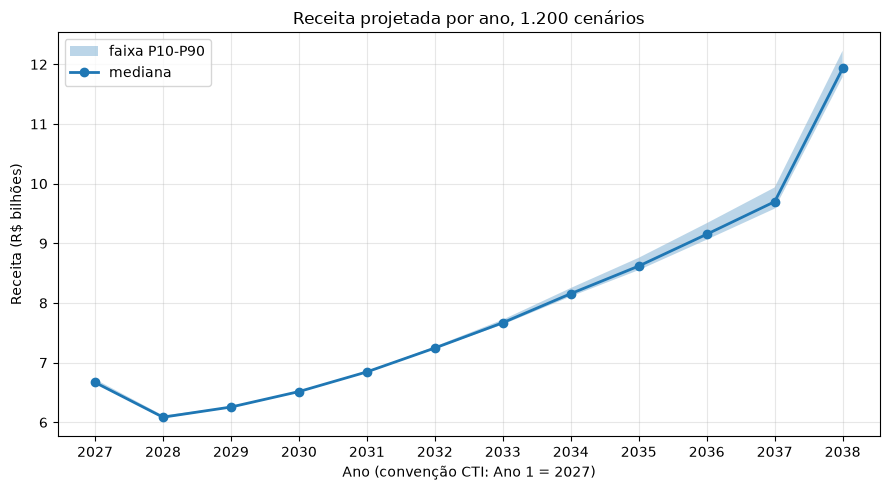

valores em R$ bilhões; largura = P90 - P10
          p10  mediana     p90  largura  cv_%
ano_n                                        
1       6.657    6.669   6.723    0.066  0.53
2       6.070    6.086   6.115    0.045  0.69
3       6.245    6.256   6.260    0.015  0.89
4       6.505    6.515   6.519    0.013  1.12
5       6.841    6.845   6.849    0.007  1.34
6       7.234    7.245   7.271    0.037  1.57
7       7.640    7.669   7.720    0.080  1.82
8       8.109    8.156   8.251    0.142  2.08
9       8.551    8.619   8.758    0.207  2.36
10      9.060    9.152   9.337    0.276  2.64
11      9.581    9.698   9.936    0.355  2.94
12     11.787   11.930  12.228    0.441  2.76


In [18]:
import matplotlib.pyplot as plt

receita = nomeadas[nomeadas["conta_norm"] == "DRE - Receita"]
faixa = receita.groupby("ano_n")["valor"].agg(
    p10=lambda s: s.quantile(0.10),
    mediana="median",
    p90=lambda s: s.quantile(0.90),
) / 1e9

# Coeficiente de variação: desvio padrão / média, em %
cv = receita.groupby("ano_n")["valor"].agg(lambda s: s.std() / s.mean() * 100)

PASTA_IMG = raiz / "imagens"
PASTA_IMG.mkdir(exist_ok=True)
anos_rotulo = [str(2026 + a) for a in faixa.index]   # convenção CTI: Ano 1 = 2027

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(faixa.index, faixa["p10"], faixa["p90"], alpha=0.30, label="faixa P10-P90")
ax.plot(faixa.index, faixa["mediana"], marker="o", linewidth=2, label="mediana")
ax.set_title("Receita projetada por ano, 1.200 cenários")
ax.set_xlabel("Ano (convenção CTI: Ano 1 = 2027)")
ax.set_ylabel("Receita (R$ bilhões)")
ax.set_xticks(faixa.index)
ax.set_xticklabels(anos_rotulo)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_IMG / "01_receita_por_ano.png", dpi=150)
plt.show()

tabela = faixa.round(3)
tabela["largura"] = (faixa["p90"] - faixa["p10"]).round(3)
tabela["cv_%"] = cv.round(2)
print("valores em R$ bilhões; largura = P90 - P10")
print(tabela.to_string())

**O que o gráfico mostra:**

1. A receita cai de 2027 para 2028 e depois cresce de forma sustentada até 2037.
2. Em 2038 (Ano 12) há um salto de cerca de 23%. **A CTI confirmou que o Ano 12 é o encerramento da
   concessão**, com liquidação de direitos e obrigações, o que ajuda a entender por que ele se comporta
   diferente dos demais.
3. A faixa P10-P90 é estreita: o coeficiente de variação da receita vai de **0,53% (2027) a 2,94% (2037)**.
   Os cenários quase não divergem sobre a receita.
4. O coeficiente de variação cresce todos os anos até 2037, mas a largura da faixa P10-P90 não: ela se
   estreita de 2027 a 2031 (de 66 para 7 milhões de reais) e só depois se alarga. Os dados não mostram,
   sozinhos, a causa desse comportamento.

A faixa P10-P90 descreve a dispersão entre cenários simulados. Não é intervalo de confiança.

### Explorar: como o resultado se distribui entre os cenários

Segunda pergunta: fixando um ano, quanto os 1.200 cenários discordam sobre o lucro?

**Escolha do gráfico:** histograma. Ele responde "quantos cenários caem em cada faixa de
valor", que é exatamente a pergunta. As linhas verticais marcam P10, mediana e P90, os
mesmos números que vão virar KPI no dashboard.


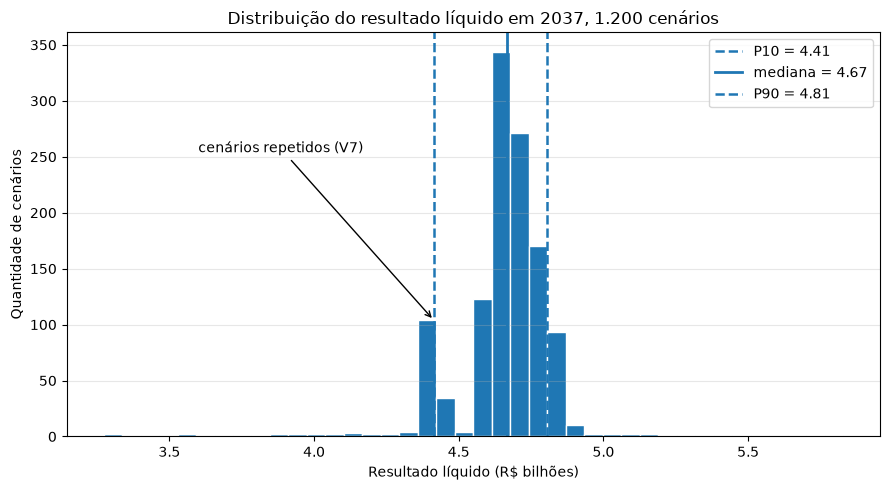

cenários: 1200 | sem cópias: 1107
mínimo: 3.27 | máximo: 5.83 | mediana: 4.67 (R$ bilhões)

     todos os cenários  sem cópias
P5               4.414       4.458
P10              4.414       4.601
P50              4.668       4.680
P90              4.806       4.810
P95              4.840       4.845

resultados líquidos negativos, somando os 12 anos: 0 de 14400


In [19]:
import numpy as np

ANO = 11
resultado = p.xs(ANO, level="ano_n")["DRE - Resultado Líquido"] / 1e9
sem_copias = resultado[~copia.loc[resultado.index].values]

p10, p50, p90 = resultado.quantile(0.10), resultado.median(), resultado.quantile(0.90)
# Resultado dos cenários repetidos identificados na V7 (todos têm o mesmo valor)
valor_repetido = resultado.loc[repetidas.index].unique()[0]

fig, ax = plt.subplots(figsize=(9, 5))
contagens, limites, _ = ax.hist(resultado, bins=40, edgecolor="white")
altura = contagens[np.searchsorted(limites, valor_repetido, side="right") - 1]  # barra dos repetidos
ax.axvline(p10, linestyle="--", linewidth=1.8, label=f"P10 = {p10:.2f}")
ax.axvline(p50, linestyle="-", linewidth=2.0, label=f"mediana = {p50:.2f}")
ax.axvline(p90, linestyle="--", linewidth=1.8, label=f"P90 = {p90:.2f}")
ax.annotate("cenários repetidos (V7)", xy=(valor_repetido, altura), xytext=(3.6, altura + 150),
            arrowprops=dict(arrowstyle="->"))
ax.set_title(f"Distribuição do resultado líquido em {2026 + ANO}, 1.200 cenários")
ax.set_xlabel("Resultado líquido (R$ bilhões)")
ax.set_ylabel("Quantidade de cenários")
ax.grid(alpha=0.3, axis="y")
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_IMG / "02_distribuicao_resultado_ano11.png", dpi=150)
plt.show()

# Efeito das cópias nos percentis
quantis = [0.05, 0.10, 0.50, 0.90, 0.95]
comparacao = pd.DataFrame({
    "todos os cenários": resultado.quantile(quantis),
    "sem cópias": sem_copias.quantile(quantis),
}).round(3)
comparacao.index = ["P5", "P10", "P50", "P90", "P95"]
print("cenários:", len(resultado), "| sem cópias:", len(sem_copias))
print(f"mínimo: {resultado.min():.2f} | máximo: {resultado.max():.2f} | mediana: {p50:.2f} (R$ bilhões)")
print()
print(comparacao.to_string())
print()

# Prejuízo: conferido em todos os anos, e não só no ano do gráfico
todos_resultados = p["DRE - Resultado Líquido"]
print("resultados líquidos negativos, somando os 12 anos:", int((todos_resultados < 0).sum()),
      "de", int(todos_resultados.notna().sum()))

**O que o gráfico mostra:**

1. A distribuição é concentrada: 90% dos cenários ficam entre 4,41 e 4,84 bilhões de reais (P5 e P95),
   com mediana de 4,67 bilhões; os extremos são 3,27 e 5,83 bilhões. **Nenhum cenário registra prejuízo**,
   nem nesse ano nem nos demais: os 14.400 resultados de cenário e ano são positivos.
2. A barra isolada perto de 4,41 bilhões é formada pelos **cenários com trajetória idêntica** (V7).
   A versão de 29/08 deste notebook interpretou isso como um "piso no modelo"; a V7 mostra que são
   cenários repetidos, todos entre `Cen_01001` e `Cen_01200`.
3. **O efeito aparece nos percentis:** com todos os cenários, P5 e P10 são iguais (4,414 bilhões) porque
   caem dentro do bloco repetido. Sem as cópias, os dois se separam (4,458 e 4,601 bilhões).
   Qualquer KPI baseado em percentis precisa decidir, e documentar, se usa ou não esses cenários.

### Explorar: a dispersão da receita e do caixa

A receita quase não varia entre os cenários. Para ver como a variação da simulação se distribui, a receita é
comparada com a geração de caixa do ano por duas medidas: o **desvio padrão**, em valor absoluto, e o
**coeficiente de variação** (CV, desvio padrão dividido pela média), que é relativo. O CV usa o valor
absoluto da média, porque a geração de caixa é negativa em alguns anos.

In [20]:
def dispersao(conta):
    """Média, desvio padrão amostral e CV da conta, ano a ano, entre os 1.200 cenários."""
    por_ano = p[conta].groupby(level="ano_n")
    media, desvio = por_ano.mean(), por_ano.std()
    return pd.DataFrame({"media_mi": media / 1e6, "desvio_mi": desvio / 1e6,
                         "cv_%": desvio / media.abs() * 100})


disp = pd.concat({"receita": dispersao("DRE - Receita"),
                  "geracao_de_caixa": dispersao("FLU - Geração de Caixa")}, axis=1).round(1)
disp.index = [2026 + a for a in disp.index]
print("valores em R$ milhões")
print(disp.to_string())
print()
menor = (disp[("geracao_de_caixa", "desvio_mi")] < disp[("receita", "desvio_mi")]).sum()
print("anos em que o desvio da geração de caixa é menor que o da receita:", menor, "de", len(disp))

valores em R$ milhões
      receita                geracao_de_caixa                 
     media_mi desvio_mi cv_%         media_mi desvio_mi   cv_%
2027   6679.1      35.1  0.5            343.3     182.6   53.2
2028   6089.7      42.0  0.7           -240.3     117.3   48.8
2029   6254.8      55.5  0.9            713.2      62.1    8.7
2030   6514.3      72.7  1.1           -624.3      63.7   10.2
2031   6845.6      91.8  1.3           -709.8     224.8   31.7
2032   7248.5     113.7  1.6            -21.8      42.1  193.2
2033   7673.5     139.6  1.8            146.6      80.1   54.6
2034   8166.0     170.0  2.1            880.3     166.9   19.0
2035   8633.4     203.7  2.4            450.9     173.0   38.4
2036   9170.8     242.3  2.6            284.9     136.4   47.9
2037   9723.0     285.4  2.9            793.2     169.4   21.4
2038  11962.4     330.3  2.8          -2351.3    1019.7   43.4

anos em que o desvio da geração de caixa é menor que o da receita: 7 de 12


**O que a tabela mostra:**

1. Pelo coeficiente de variação, a geração de caixa parece muito mais incerta que a receita: de 9% a 193%,
   contra menos de 3%.
2. Esse contraste engana. A média da geração de caixa é pequena e muda de sinal entre os anos; em 2032 ela
   fica perto de zero, e é isso que leva o CV a 193%. O CV só compara bem variáveis com médias de mesmo
   sinal e longe de zero.
3. Em valor absoluto, o desvio padrão da geração de caixa (de 42 a 225 milhões de reais até 2037) é da
   mesma ordem do desvio da receita (de 35 a 285 milhões) e é menor que ele em 7 dos 12 anos. No
   encerramento, o desvio da geração de caixa sobe para cerca de 1 bilhão.
4. Portanto, o CV sozinho não mostra que a incerteza da simulação está concentrada no caixa. As próximas
   análises comparam variáveis de níveis diferentes também por medidas absolutas.

## Achados consolidados da fase Entender os Dados (revisão de 22/09/2026)

| # | Verificação | Resultado | Impacto |
|---|---|---|---|
| V1 | Todo ano tem 69 contas | Anos 1 e 2 têm 68; **Ano 12 tem 42** | O Ano 12 é o encerramento da concessão (confirmado pela CTI) |
| V2 | Grupos de ano e cenário do mesmo tamanho | Três tamanhos: 42, 68 e 69 | O padrão vale para todos os cenários |
| V3 | (ano, cenário, conta) é chave única | 28.800 repetições, **todas** em linhas sem nome | Nenhuma conta financeira duplicada |
| V4 | O balanço fecha | **Fecha nos 14.400 grupos** com `Ativo + Passivo`, com resíduo máximo de centavos; a estrutura também fecha | Identidade dos totais conferida. O achado anterior de 15,2 bilhões era erro de sinal do teste |
| V5 | 1ª linha sem nome = resíduo | Diferença máxima de cerca de 0,0001 | É conferência do modelo, não taxa nem conta |
| V6 | Fluxo de caixa fecha | **Fecha nos 14.400 grupos** | Regra de validação para os KPIs |
| V7 | Cenários todos diferentes | **94 cenários idênticos** (1.107 distintos, comparação exata), todos entre `Cen_01001` e `Cen_01200` | Altera os percentis (P5 = P10 com todos os cenários). Analisar com e sem cópias |
| Exploração | Resultado líquido | Positivo nos 14.400 registros de cenário e ano | Nenhum cenário tem prejuízo |
| Exploração | Dispersão entre cenários | CV da receita de 0,53% a 2,94%; CV do caixa de 9% a 193%, inflado por médias perto de zero | Comparar a dispersão também em valor absoluto: o CV sozinho não mostra onde está a incerteza |

### Pontos em aberto para a CTI

1. Os 94 cenários idênticos são intencionais ou artefato da simulação? Devem entrar na análise?
2. `BAL - Passivo Circulante` é positivo em 62% dos registros (8.966 de 14.400), acompanhando `BAL - Empréstimos`.
   Qual a leitura correta desse sinal? (necessário para os índices de liquidez)
3. Qual é a memória de cálculo do `DRE - EBITDA`? Ele não reconcilia com o Resultado Operacional antes da
   Depreciação e Amortização (`Resultado Operacional - D&A`, com a D&A negativa na base).
4. `BAL - Emprést` e `BAL - Outros deb` são contas distintas de `BAL - Empréstimos` e `BAL - Outros Débitos`?
5. Há restrição para publicar valores agregados no repositório público?

### Próxima fase

A **Preparação dos Dados** (CRISP-DM) está no notebook `02_preparacao.ipynb` e no script `src/prepara.py`,
que geram a base analítica em `src/data/processed/`.